Import Library

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

Import Data

In [73]:
data = pd.read_csv('encoded_data.csv')
print(data.info())
data.head()
data_model = data[data['Cluster_ID_Outlier'] == 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Columns: 139 entries, Profession_ข้าราชการ to T_Trial_ไม่ลอง
dtypes: float64(82), int64(57)
memory usage: 181.5 KB
None


predict customer segment

=== TRAIN ===
Accuracy: 0.9623
                             precision    recall  f1-score   support

         Cluster_ID_ชอบกาแฟ       1.00      0.94      0.97        53
           Cluster_ID_ชอบชา       1.00      0.94      0.97        53
Cluster_ID_ชอบทั้งกาแฟและชา       0.90      1.00      0.95        53

                   accuracy                           0.96       159
                  macro avg       0.97      0.96      0.96       159
               weighted avg       0.97      0.96      0.96       159

=== TEST ===
Accuracy: 0.9412
                             precision    recall  f1-score   support

         Cluster_ID_ชอบกาแฟ       0.86      1.00      0.92         6
           Cluster_ID_ชอบชา       1.00      0.82      0.90        11
Cluster_ID_ชอบทั้งกาแฟและชา       0.94      1.00      0.97        17

                   accuracy                           0.94        34
                  macro avg       0.93      0.94      0.93        34
               weighted avg       0.9

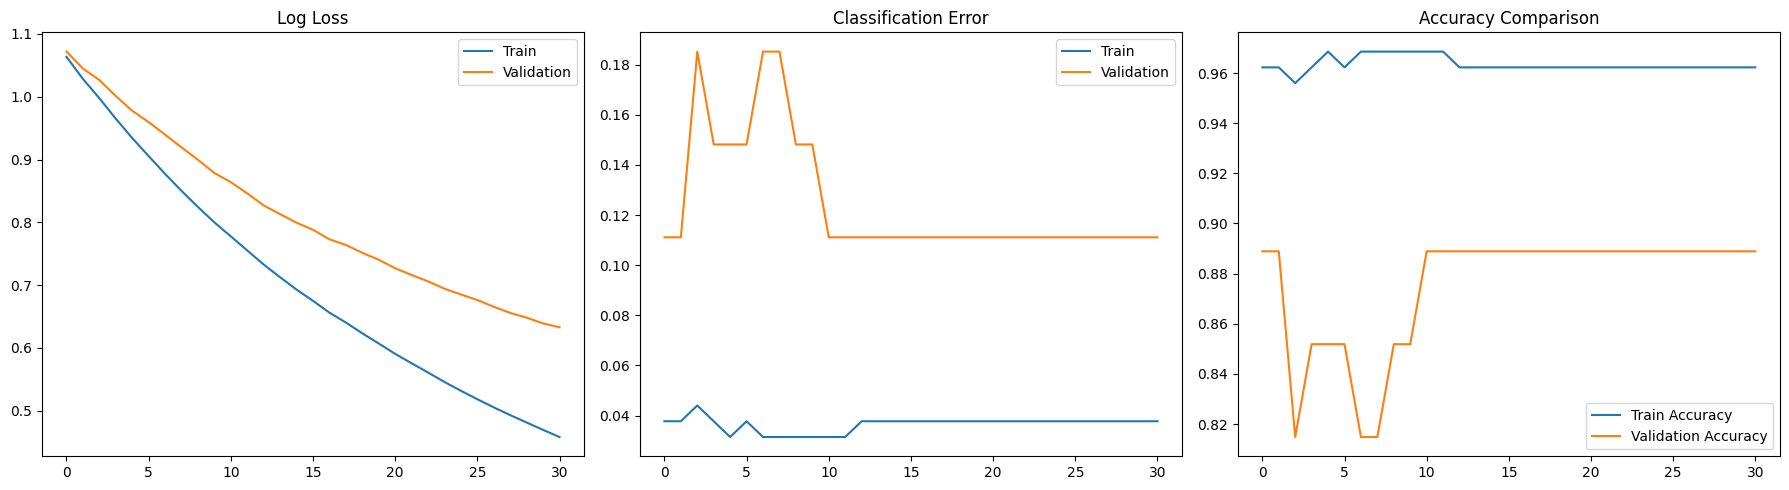


Cross-val Accuracy: 0.9245 (+/- 0.0341)


In [83]:
# =========================
# 1. LOAD DATA
# =========================
data_model = pd.read_csv('encoded_data.csv')

# =========================
# 2. FEATURE SELECTION
# =========================
# ใช้ feature พื้นฐาน + behavior
age_cols = ['Age']
usage_cols = ['S_Frequency', 'S_Screentime']

# เลือก column ที่เกี่ยวกับพฤติกรรม
behavior_cols = [
    c for c in data_model.columns
    if any(k in c for k in ['Channel', 'Frequency', 'Favorite', 'Occasion'])
]

feature_cols = age_cols + usage_cols + behavior_cols

# ตัด column target ออก
feature_cols = [c for c in feature_cols if 'Cluster_ID' not in c]

# =========================
# 3. TARGET
# =========================
cluster_cols = [
    c for c in data_model.columns
    if c.startswith('Cluster_ID_') and 'Outlier' not in c
]

# สร้าง label จาก one-hot
data_model['target'] = data_model[cluster_cols].idxmax(axis=1)

# ลบ class ที่มีข้อมูลน้อยเกินไป
counts = data_model['target'].value_counts()
valid_clusters = counts[counts > 5].index
data_model = data_model[data_model['target'].isin(valid_clusters)]

X = data_model[feature_cols]
y = data_model['target']

# encode label → ตัวเลข
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# =========================
# 4. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# =========================
# 5. VALIDATION SPLIT (ใช้สำหรับ early stopping)
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# =========================
# 6. SMOTE (แก้ class imbalance)
# =========================
smote = SMOTE(random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

# =========================
# 7. MODEL
# =========================
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=2,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    objective='multi:softprob',
    eval_metric=["mlogloss", "merror"],
    early_stopping_rounds=30
)

# =========================
# 8. TRAIN
# =========================
# ใช้ validation set → ไม่มี leakage
#แปลงเป็น numpy ก่อนเข้า model
X_tr_res = X_tr_res.values
X_val = X_val.values
X_test = X_test.values

xgb_model.fit(
    X_tr_res, y_tr_res,
    eval_set=[(X_tr_res, y_tr_res), (X_val, y_val)],
    verbose=False
)

# =========================
# 9. EVALUATION
# =========================
y_pred_train = xgb_model.predict(X_tr_res)
y_pred_test = xgb_model.predict(X_test)

print("=== TRAIN ===")
print(f"Accuracy: {accuracy_score(y_tr_res, y_pred_train):.4f}")
print(classification_report(y_tr_res, y_pred_train, target_names=le.classes_))

print("=== TEST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

# =========================
# 10. LEARNING CURVE
# =========================
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(epochs)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- Log Loss ---
ax[0].plot(x_axis, results['validation_0']['mlogloss'], label='Train')
ax[0].plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
ax[0].set_title('Log Loss')
ax[0].legend()

# --- Error ---
ax[1].plot(x_axis, results['validation_0']['merror'], label='Train')
ax[1].plot(x_axis, results['validation_1']['merror'], label='Validation')
ax[1].set_title('Classification Error')
ax[1].legend()

# --- Accuracy  ---
train_acc = [1 - e for e in results['validation_0']['merror']]
val_acc = [1 - e for e in results['validation_1']['merror']]

ax[2].plot(x_axis, train_acc, label='Train Accuracy')
ax[2].plot(x_axis, val_acc, label='Validation Accuracy')
ax[2].set_title('Accuracy Comparison')
ax[2].legend()

plt.tight_layout()
plt.show()

# =========================
# 11. CROSS VALIDATION
# =========================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=2,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42,
        objective='multi:softprob'
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X_train.values, y_train, cv=cv) # Convert X_train to numpy array here

print(f"\nCross-val Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

save model

In [ ]:
import joblib

# save ทั้ง 3 model
joblib.dump(xgb_model, "customer_model.pkl")


# save feature columns ด้วย (สำคัญมาก)
joblib.dump(feature_cols, "feature_cols.pkl")

['feature_cols.pkl']